In [ ]:
import os
import sys
import csv
import math
import time
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torchvision.ops import nms

# ── your modules (must be in the same directory) ──────────────────────
from dataset import build_dataloaders
from utils   import YOLOv11
from loss    import v8DetectionLoss

# ── device ────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

YAML_PATH      = 'dataset/data.yaml'   # path to your data.yaml
SAVE_DIR       = Path('checkpoints/train')    # where checkpoints + logs go

MODEL_NAME     = 'yolo11n'             # yolo11n / s / m / l / x
NC             = 1                     # number of classes (polyp = 1)
IMG_SIZE       = 640

EPOCHS         = 300
BATCH_SIZE     = 16
NUM_WORKERS    = 4                    # 0 on Windows if errors else 4

LR             = 1e-3                  # peak learning rate (AdamW)
LR_MIN         = 1e-5                  # minimum LR at end of cosine decay
WEIGHT_DECAY   = 5e-4
WARMUP_EPOCHS  = 3                     # linear warmup for first N epochs

GRAD_CLIP      = 10.0                  # max gradient norm
PATIENCE       = 50                    # early stop if no mAP improvement
MAP_EVERY      = 1                     # compute NMS+mAP every N epochs

# NMS thresholds
CONF_THRESH    = 0.25
IOU_THRESH     = 0.45

SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'save dir : {SAVE_DIR.resolve()}')

device : cuda
GPU    : NVIDIA GeForce RTX 4080 Laptop GPU
save dir : D:\vinod_FYP\checkpoints_1\train


In [3]:
# ── dataloaders ───────────────────────────────────────────────────────
# train: augment=True  (letterbox + HSV + hflip)
# val  : augment=False (letterbox only)
train_loader, val_loader = build_dataloaders(
    YAML_PATH,
    img_size    = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
)
print(f'train batches : {len(train_loader)}')
print(f'val   batches : {len(val_loader)}')

# ── model ─────────────────────────────────────────────────────────────
model = YOLOv11(model_name=MODEL_NAME, nc=NC).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'model  : {MODEL_NAME}  ({n_params:.1f}M params)')

# ── optimizer (AdamW) ─────────────────────────────────────────────────
# separate weight decay: apply to weights only, not biases or BN params
decay_params    = [p for n, p in model.named_parameters()
                   if p.requires_grad and p.ndim > 1]
no_decay_params = [p for n, p in model.named_parameters()
                   if p.requires_grad and p.ndim <= 1]

optimizer = torch.optim.AdamW([
    {'params': decay_params,    'weight_decay': WEIGHT_DECAY},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=LR)

# ── loss ──────────────────────────────────────────────────────────────
criterion = v8DetectionLoss(nc=NC).to(DEVICE)

print('optimizer, loss ready.')

[PolyDataset] split=train  images=4993  augment=True
[PolyDataset] split=valid  images=714  augment=False
train batches : 313
val   batches : 45
model  : yolo11n  (2.3M params)
optimizer, loss ready.


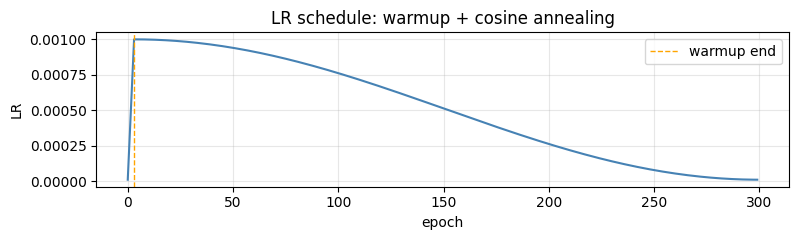

In [4]:
def lr_lambda(epoch):
    """Returns LR scale factor for current epoch."""
    if epoch < WARMUP_EPOCHS:
        # linear warmup: 0.01 → 1.0 over warmup epochs
        return 0.01 + (1.0 - 0.01) * (epoch / max(WARMUP_EPOCHS, 1))
    else:
        # cosine annealing from LR down to LR_MIN
        progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
        cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
        min_frac = LR_MIN / LR
        return min_frac + (1.0 - min_frac) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# quick sanity plot
lrs = [lr_lambda(e) * LR for e in range(EPOCHS)]
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(lrs, color='steelblue', linewidth=1.5)
ax.axvline(WARMUP_EPOCHS, color='orange', linestyle='--', linewidth=1, label='warmup end')
ax.set_xlabel('epoch'); ax.set_ylabel('LR')
ax.set_title('LR schedule: warmup + cosine annealing')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
def apply_nms(predictions, conf_thresh=CONF_THRESH, iou_thresh=IOU_THRESH):
    """
    Apply NMS to raw model output.

    predictions : [B, 8400, 5]  (cx, cy, w, h, score)  pixel space
                  model in eval mode already decoded boxes to xywh

    Returns list of length B, each element:
        np.ndarray [N, 6]  (x1, y1, x2, y2, score, class)  or empty
    """
    results = []
    for pred in predictions:          # pred: [8400, 5]
        scores = pred[:, 4]
        mask   = scores > conf_thresh
        pred   = pred[mask]

        if pred.shape[0] == 0:
            results.append(np.zeros((0, 6), dtype=np.float32))
            continue

        # xywh → xyxy
        cx, cy, w, h = pred[:, 0], pred[:, 1], pred[:, 2], pred[:, 3]
        x1 = cx - w / 2;  y1 = cy - h / 2
        x2 = cx + w / 2;  y2 = cy + h / 2
        boxes  = torch.stack([x1, y1, x2, y2], dim=1)
        scores = pred[:, 4]

        keep   = nms(boxes, scores, iou_thresh)
        boxes  = boxes[keep].cpu().numpy()
        scores = scores[keep].cpu().numpy()
        labels = np.zeros(len(keep), dtype=np.float32)  # nc=1, class always 0

        results.append(
            np.concatenate([boxes, scores[:, None], labels[:, None]], axis=1)
        )
    return results


def box_iou_numpy(box1, box2):
    """
    box1 : [N, 4]  xyxy
    box2 : [M, 4]  xyxy
    Returns [N, M] IoU matrix
    """
    area1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])  # [N]
    area2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])  # [M]

    inter_x1 = np.maximum(box1[:, None, 0], box2[None, :, 0])  # [N, M]
    inter_y1 = np.maximum(box1[:, None, 1], box2[None, :, 1])
    inter_x2 = np.minimum(box1[:, None, 2], box2[None, :, 2])
    inter_y2 = np.minimum(box1[:, None, 3], box2[None, :, 3])

    inter = np.maximum(inter_x2 - inter_x1, 0) * np.maximum(inter_y2 - inter_y1, 0)
    union = area1[:, None] + area2[None, :] - inter + 1e-7
    return inter / union


def compute_ap(recall, precision):
    """Compute area under PR curve using 101-point interpolation."""
    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[1.0], precision, [0.0]])
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    idx  = np.where(mrec[1:] != mrec[:-1])[0]
    return np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])


def compute_map(all_preds, all_gts, iou_thresholds=None):
    """
    Compute mAP@0.5 and mAP@0.5:0.95.

    all_preds : list of np.ndarray [N, 6]  (x1,y1,x2,y2, score, cls)
    all_gts   : list of np.ndarray [M, 5]  (cls, cx,cy,w,h) normalized
                GT boxes are still in normalized format — we convert below

    Returns: map50 (float), map5095 (float), precision (float), recall (float)
    """
    if iou_thresholds is None:
        iou_thresholds = np.linspace(0.5, 0.95, 10)

    ap_per_threshold = []

    for iou_thr in iou_thresholds:
        tp_list, conf_list, n_gt_total = [], [], 0

        for preds, gts in zip(all_preds, all_gts):
            # convert GT from normalized cxcywh → pixel xyxy (IMG_SIZE=640)
            if gts.shape[0] > 0:
                gts_px = gts[gts[:, 1:].sum(-1) > 0]   # remove padding
                if gts_px.shape[0] > 0:
                    cx  = gts_px[:, 1] * IMG_SIZE
                    cy  = gts_px[:, 2] * IMG_SIZE
                    w   = gts_px[:, 3] * IMG_SIZE
                    h   = gts_px[:, 4] * IMG_SIZE
                    gt_boxes = np.stack(
                        [cx - w/2, cy - h/2, cx + w/2, cy + h/2], axis=1
                    )
                else:
                    gt_boxes = np.zeros((0, 4))
            else:
                gt_boxes = np.zeros((0, 4))

            n_gt_total += len(gt_boxes)
            matched = np.zeros(len(gt_boxes), dtype=bool)

            if preds.shape[0] == 0:
                continue

            # sort preds by descending confidence
            order  = np.argsort(-preds[:, 4])
            preds  = preds[order]

            for pred in preds:
                conf_list.append(pred[4])
                if len(gt_boxes) == 0:
                    tp_list.append(0)
                    continue
                ious    = box_iou_numpy(pred[:4][None], gt_boxes)[0]  # [M]
                best_i  = np.argmax(ious)
                if ious[best_i] >= iou_thr and not matched[best_i]:
                    tp_list.append(1)
                    matched[best_i] = True
                else:
                    tp_list.append(0)

        if len(tp_list) == 0 or n_gt_total == 0:
            ap_per_threshold.append(0.0)
            continue

        tp_arr   = np.array(tp_list, dtype=np.float32)
        conf_arr = np.array(conf_list)
        order    = np.argsort(-conf_arr)
        tp_arr   = tp_arr[order]

        cum_tp  = np.cumsum(tp_arr)
        cum_fp  = np.cumsum(1 - tp_arr)
        recall  = cum_tp / (n_gt_total + 1e-7)
        precision = cum_tp / (cum_tp + cum_fp + 1e-7)

        ap_per_threshold.append(compute_ap(recall, precision))

    # precision/recall at iou=0.5 for logging
    final_prec = precision[-1] if len(tp_list) > 0 else 0.0
    final_rec  = recall[-1]    if len(tp_list) > 0 else 0.0

    map50   = ap_per_threshold[0]
    map5095 = float(np.mean(ap_per_threshold))
    return map50, map5095, float(final_prec), float(final_rec)


print('NMS + mAP helpers ready.')

NMS + mAP helpers ready.


In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch):
    """
    One full pass over the training set.

    Returns dict with mean losses for the epoch:
        {'total', 'box', 'cls', 'dfl', 'n_fg'}
    """
    model.train()
    totals = defaultdict(float)
    n_batches = len(loader)
    t0 = time.time()

    for i, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(device, non_blocking=True)      # [B, 3, 640, 640]
        labels = labels.to(device, non_blocking=True)    # [B, max_gt, 5]

        # ── forward ───────────────────────────────────────────────────
        # model.train() → returns list of 3 feature maps, NOT decoded boxes
        raw_preds = model(imgs)                          # [B,65,H,W] × 3

        # ── loss ──────────────────────────────────────────────────────
        loss, loss_dict = criterion(raw_preds, labels, img_size=IMG_SIZE)

        # ── backward ──────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()

        # gradient clipping — prevents exploding gradients early in training
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

        optimizer.step()

        # ── accumulate ────────────────────────────────────────────────
        for k, v in loss_dict.items():
            totals[k] += v

        # ── progress print every 20 batches ───────────────────────────
        if (i + 1) % 20 == 0 or (i + 1) == n_batches:
            elapsed = time.time() - t0
            print(f'  [{epoch:3d}][{i+1:4d}/{n_batches}]  '
                  f'loss={loss_dict["total"]:.4f}  '
                  f'box={loss_dict["box"]:.4f}  '
                  f'cls={loss_dict["cls"]:.4f}  '
                  f'dfl={loss_dict["dfl"]:.4f}  '
                  f'n_fg={loss_dict["n_fg"]:3d}  '
                  f'({elapsed:.0f}s)', end='\r')
            

    print()  # newline after \r
    return {k: v / n_batches for k, v in totals.items()}

In [7]:
def val_one_epoch(model, loader, criterion, device, epoch, compute_metrics=False):
    """
    One pass over the validation set.

    compute_metrics : if True, also run NMS and compute mAP

    Returns
    -------
    loss_dict : {'total', 'box', 'cls', 'dfl'}  mean over val set
    metrics   : {'map50', 'map5095', 'precision', 'recall'}
                or None if compute_metrics=False
    """
    model.eval()
    totals   = defaultdict(float)
    n_batches = len(loader)

    all_preds = []   # for mAP — accumulated across all batches
    all_gts   = []

    with torch.no_grad():
        for i, (imgs, labels) in enumerate(loader):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # ── val loss: force ONLY the detect head to train mode
            # This prevents BatchNorm from updating its running stats on val data!
            model.head.detect.training = True
            raw_preds = model(imgs)
            model.head.detect.training = False   # switch quickly back
            
            _, loss_dict = criterion(raw_preds, labels, img_size=IMG_SIZE)
            for k, v in loss_dict.items():
                totals[k] += v

            # ── mAP: need decoded boxes → eval mode
            if compute_metrics:
                # We don't need model.eval() here anymore, it never left eval mode!
                decoded = model(imgs)   # [B, 5, 8400]  (cx,cy,w,h,score)
                # decoded: [B, nc+4, 8400] → permute to [B, 8400, nc+4]
                decoded = decoded.permute(0, 2, 1)   # [B, 8400, 5]

                batch_preds = apply_nms(decoded, CONF_THRESH, IOU_THRESH)
                all_preds.extend(batch_preds)
                all_gts.extend(labels.cpu().numpy())

           

    model.eval()   # restore eval mode

    mean_losses = {k: v / n_batches for k, v in totals.items()}

    metrics = None
    if compute_metrics:
        map50, map5095, prec, rec = compute_map(all_preds, all_gts)
        metrics = {
            'map50'    : map50,
            'map5095'  : map5095,
            'precision': prec,
            'recall'   : rec,
        }

    return mean_losses, metrics

### resuming training 

In [ ]:
# import time
# import csv
# import torch
# from utils import apply_nms, compute_map

# print(f"Resuming training up to {EPOCHS} epochs...")
# print(f"mAP computed every {MAP_EVERY} epochs | early stop patience={PATIENCE}")
# print("-" * 80)

# # ── 1. Load Checkpoint (Resume Logic) ───────────────────────────────────────
# RESUME_PATH = SAVE_DIR / 'last.pt'
# if RESUME_PATH.exists():
#     ckpt = torch.load(RESUME_PATH, map_location=DEVICE)
#     model.load_state_dict(ckpt['model'])
#     optimizer.load_state_dict(ckpt['optimizer'])
#     scheduler.load_state_dict(ckpt['scheduler'])
#     START_EPOCH = ckpt['epoch'] + 1
#     best_map50 = ckpt.get('best_map50', 0.0)
#     epochs_without_improvement = ckpt.get('patience', 0)
#     print(f"Successfully resumed from Epoch {ckpt['epoch']}! Best mAP50 so far: {best_map50:.4f}")
# else:
#     START_EPOCH = 1
#     best_map50 = 0.0
#     epochs_without_improvement = 0
#     print("No checkpoint found! Starting from Epoch 1.")

# # Initialize the CSV file with headers if it doesn't exist
# csv_path = SAVE_DIR / 'results.csv'
# csv_cols = [
#     'epoch',
#     'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
#     'val/box_loss',   'val/cls_loss',   'val/dfl_loss',
#     'metrics/precision(B)', 'metrics/recall(B)',
#     'metrics/mAP50(B)',     'metrics/mAP50-95(B)',
#     'lr',
# ]
# if not csv_path.exists():
#     with open(csv_path, 'w', newline='') as f:
#         csv.writer(f).writerow(csv_cols)

# # ── 2. The Main Epoch Loop ──────────────────────────────────────────────────
# for epoch in range(START_EPOCH, EPOCHS + 1):
#     model.train()
#     train_losses = {'box': 0.0, 'cls': 0.0, 'dfl': 0.0, 'total': 0.0}
    
#     t0 = time.time()
#     n_batches = len(train_loader)
    
#     # --- TRAINING PHASE ---
#     for i, (imgs, labels) in enumerate(train_loader):
#         imgs   = imgs.to(DEVICE, non_blocking=True).float() / 255.0
#         labels = labels.to(DEVICE, non_blocking=True)
        
#         optimizer.zero_grad()
#         raw_preds = model(imgs)
        
#         loss, loss_dict = criterion(raw_preds, labels, img_size=IMG_SIZE)
        
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
#         optimizer.step()
        
#         for k, v in loss_dict.items():
#             if k != 'n_fg':
#                 train_losses[k] += v
                
#         # ── progress print every 20 batches ───────────────────────────
#         if (i + 1) % 20 == 0 or (i + 1) == n_batches:
#             elapsed = time.time() - t0
#             print(f'  [{epoch:3d}][{i+1:4d}/{n_batches}]  '
#                   f'loss={loss_dict["total"]:.4f}  '
#                   f'box={loss_dict["box"]:.4f}  '
#                   f'cls={loss_dict["cls"]:.4f}  '
#                   f'dfl={loss_dict["dfl"]:.4f}  '
#                   f'n_fg={loss_dict["n_fg"]:3d}  '
#                   f'({elapsed:.0f}s)', end='\r')

#     print()  # force newline after batches finish
    
#     train_losses = {k: v / n_batches for k, v in train_losses.items()}

#     # Step the learning rate scheduler based on epoch
#     scheduler.step()
#     current_lr = optimizer.param_groups[0]['lr']

#     # --- VALIDATION PHASE ---
#     val_losses = {'box': 0.0, 'cls': 0.0, 'dfl': 0.0, 'total': 0.0}
#     compute_metrics = (epoch % MAP_EVERY == 0)
    
#     all_preds = []
#     all_gts   = []
    
#     model.eval()
#     with torch.no_grad():
#         for imgs, labels in val_loader:
#             imgs   = imgs.to(DEVICE, non_blocking=True).float() / 255.0
#             labels = labels.to(DEVICE, non_blocking=True)
            
#             # ── val loss: force ONLY the detect head to train mode
#             model.head.detect.training = True
#             raw_preds = model(imgs)
#             model.head.detect.training = False   # switch quickly back
            
#             _, loss_dict = criterion(raw_preds, labels, img_size=IMG_SIZE)
#             for k, v in loss_dict.items():
#                 if k != 'n_fg':
#                     val_losses[k] += v
                    
#             # ── mAP: need decoded boxes → eval mode
#             if compute_metrics:
#                 decoded = model(imgs)
#                 batch_preds = apply_nms(decoded, CONF_THRESH, IOU_THRESH)
#                 all_preds.extend(batch_preds)
#                 all_gts.extend(labels.cpu().numpy())

#     n_val_batches = len(val_loader)
#     val_losses = {k: v / n_val_batches for k, v in val_losses.items()}

#     # --- METRICS & SAVING ---
#     last_map50   = 0.0
#     last_map5095 = 0.0
#     last_prec    = 0.0
#     last_rec     = 0.0

#     if compute_metrics:
#         # PERFECTLY MATCHED VARIABLES: 4 requested, 4 returned!
#         last_map50, last_map5095, last_prec, last_rec = compute_map(all_preds, all_gts)

#     epoch_time = time.time() - t0
#     msg = (f"Epoch {epoch:3d}/{EPOCHS}  "
#            f"train_loss={train_losses['total']:.4f}  "
#            f"val_loss={val_losses['total']:.4f}  "
#            f"mAP50={last_map50:.4f}  mAP50-95={last_map5095:.4f}  "
#            f"lr={current_lr:.2e}  [{epoch_time:.0f}s]")

#     # Checkpoint Saves
#     ckpt_state = {
#         'epoch': epoch,
#         'model': model.state_dict(),
#         'optimizer': optimizer.state_dict(),
#         'scheduler': scheduler.state_dict(),
#         'best_map50': best_map50,
#         'patience': epochs_without_improvement
#     }
    
#     torch.save(ckpt_state, SAVE_DIR / 'last.pt')
    
#     if compute_metrics and last_map50 > best_map50:
#         best_map50 = last_map50
#         ckpt_state['best_map50'] = best_map50
#         torch.save(ckpt_state, SAVE_DIR / 'best.pt')
#         msg += " * best mAP!"
#         epochs_without_improvement = 0
#     else:
#         epochs_without_improvement += 1

#     print(msg)
    
#     # Write to CSV
#     with open(csv_path, 'a', newline='') as f:
#         csv.writer(f).writerow([
#             epoch,
#             round(train_losses['box'],  4),
#             round(train_losses['cls'],  4),
#             round(train_losses['dfl'],  4),
#             round(val_losses['box'],    4),
#             round(val_losses['cls'],    4),
#             round(val_losses['dfl'],    4),
#             round(last_prec,    4),
#             round(last_rec,     4),
#             round(last_map50,   4),
#             round(last_map5095, 4),
#             round(current_lr,   8),
#         ])

#     # Early stopping
#     if epochs_without_improvement >= PATIENCE:
#         print(f"\n[Early Stopping] No mAP improvement for {PATIENCE} epochs.")
#         break

# print("Training Pipeline Complete!")


### training from start

In [8]:
# ── CSV logger setup ──────────────────────────────────────────────────
csv_path = SAVE_DIR / 'results.csv'
csv_cols = [
    'epoch',
    'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
    'val/box_loss',   'val/cls_loss',   'val/dfl_loss',
    'metrics/precision(B)', 'metrics/recall(B)',
    'metrics/mAP50(B)',     'metrics/mAP50-95(B)',
    'lr',
]
with open(csv_path, 'w', newline='') as f:
    csv.writer(f).writerow(csv_cols)

# ── tracking state ────────────────────────────────────────────────────
best_val_loss = float('inf')
best_map50    = 0.0
last_map50    = 0.0        # carry forward on epochs we skip mAP
last_map5095  = 0.0
last_prec     = 0.0
last_rec      = 0.0
no_improve    = 0          # early stopping counter

print(f'Starting training for {EPOCHS} epochs')
print(f'mAP computed every {MAP_EVERY} epochs | early stop patience={PATIENCE}')
print('-' * 80)

for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()

    # ── train ─────────────────────────────────────────────────────────
    train_losses = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, epoch
    )

    # ── val ───────────────────────────────────────────────────────────
    compute_metrics = (epoch % MAP_EVERY == 0) or (epoch == EPOCHS)
    val_losses, metrics = val_one_epoch(
        model, val_loader, criterion, DEVICE, epoch,
        compute_metrics=compute_metrics
    )

    # ── scheduler step ────────────────────────────────────────────────
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # ── update running metrics ────────────────────────────────────────
    if metrics is not None:
        last_map50   = metrics['map50']
        last_map5095 = metrics['map5095']
        last_prec    = metrics['precision']
        last_rec     = metrics['recall']

    # ── checkpointing setup ───────────────────────────────────────────
    checkpoint = {
        'epoch'     : epoch,
        'model'     : model.state_dict(),
        'optimizer' : optimizer.state_dict(),
        'scheduler' : scheduler.state_dict(),
        'best_map50': best_map50,
        'val_loss'  : val_losses['total'],
    }

    # Save last.pt every epoch
    torch.save(checkpoint, SAVE_DIR / 'last.pt')
    
    # Track lowest validation loss for our console summary
    if val_losses['total'] < best_val_loss:
        best_val_loss = val_losses['total']

    # ── early stopping & BEST checkpointing (based on mAP@0.5) ───────
    best_flag = False
    
    if metrics is not None:
        if last_map50 > best_map50:
            best_map50  = last_map50
            no_improve  = 0
            
            # --- SAVING BEST MODEL ON MAP IMPROVEMENT ---
            torch.save(checkpoint, SAVE_DIR / 'best.pt')
            best_flag = True 
        else:
            no_improve += MAP_EVERY

    # ── CSV log ───────────────────────────────────────────────────────
    with open(csv_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            round(train_losses['box'],  4),
            round(train_losses['cls'],  4),
            round(train_losses['dfl'],  4),
            round(val_losses['box'],    4),
            round(val_losses['cls'],    4),
            round(val_losses['dfl'],    4),
            round(last_prec,    4),
            round(last_rec,     4),
            round(last_map50,   4),
            round(last_map5095, 4),
            round(current_lr,   8),
        ])

    # ── epoch summary ─────────────────────────────────────────────────
    elapsed = time.time() - t_epoch
    map_str = f'mAP50={last_map50:.4f}  mAP50-95={last_map5095:.4f}' \
              if compute_metrics else 'mAP: (skipped)'
              
    print(
        f'Epoch {epoch:3d}/{EPOCHS}  '
        f'train_loss={train_losses["total"]:.4f}  '
        f'val_loss={val_losses["total"]:.4f}  '
        f'{map_str}  '
        f'lr={current_lr:.2e}  '
        f'[{elapsed:.0f}s]'
        + (' * best mAP!' if best_flag else '')
    )

    # ── early stopping check ──────────────────────────────────────────
    if no_improve >= PATIENCE:
        print(f'\nEarly stopping: no mAP improvement for {PATIENCE} epochs.')
        break

print(f'\nTraining complete. Best val loss={best_val_loss:.4f}  Best mAP@0.5={best_map50:.4f}')
print(f'Checkpoints saved to: {SAVE_DIR.resolve()}')


Starting training for 300 epochs
mAP computed every 1 epochs | early stop patience=50
--------------------------------------------------------------------------------
  [  1][ 313/313]  loss=12.5712  box=0.4904  cls=9.4510  dfl=2.7785  n_fg= 13  (84s))
Epoch   1/300  train_loss=12.0057  val_loss=85374.1104  mAP50=0.0000  mAP50-95=0.0000  lr=3.40e-04  [100s]
  [  2][ 313/313]  loss=8.6925  box=0.4455  cls=4.4295  dfl=2.0910  n_fg= 13  (42s))
Epoch   2/300  train_loss=9.7676  val_loss=7221.9673  mAP50=0.0411  mAP50-95=0.0111  lr=6.70e-04  [53s] * best mAP!
  [  3][ 313/313]  loss=12.9728  box=0.6295  cls=9.6484  dfl=2.2849  n_fg= 13  (45s)
Epoch   3/300  train_loss=8.0460  val_loss=2217.7522  mAP50=0.3489  mAP50-95=0.1489  lr=1.00e-03  [57s] * best mAP!
  [  4][ 313/313]  loss=7.0203  box=0.3140  cls=4.0810  dfl=1.7500  n_fg= 13  (45s)
Epoch   4/300  train_loss=6.0882  val_loss=1730.9558  mAP50=0.5295  mAP50-95=0.2327  lr=1.00e-03  [56s] * best mAP!
  [  5][ 313/313]  loss=11373.7656  bo

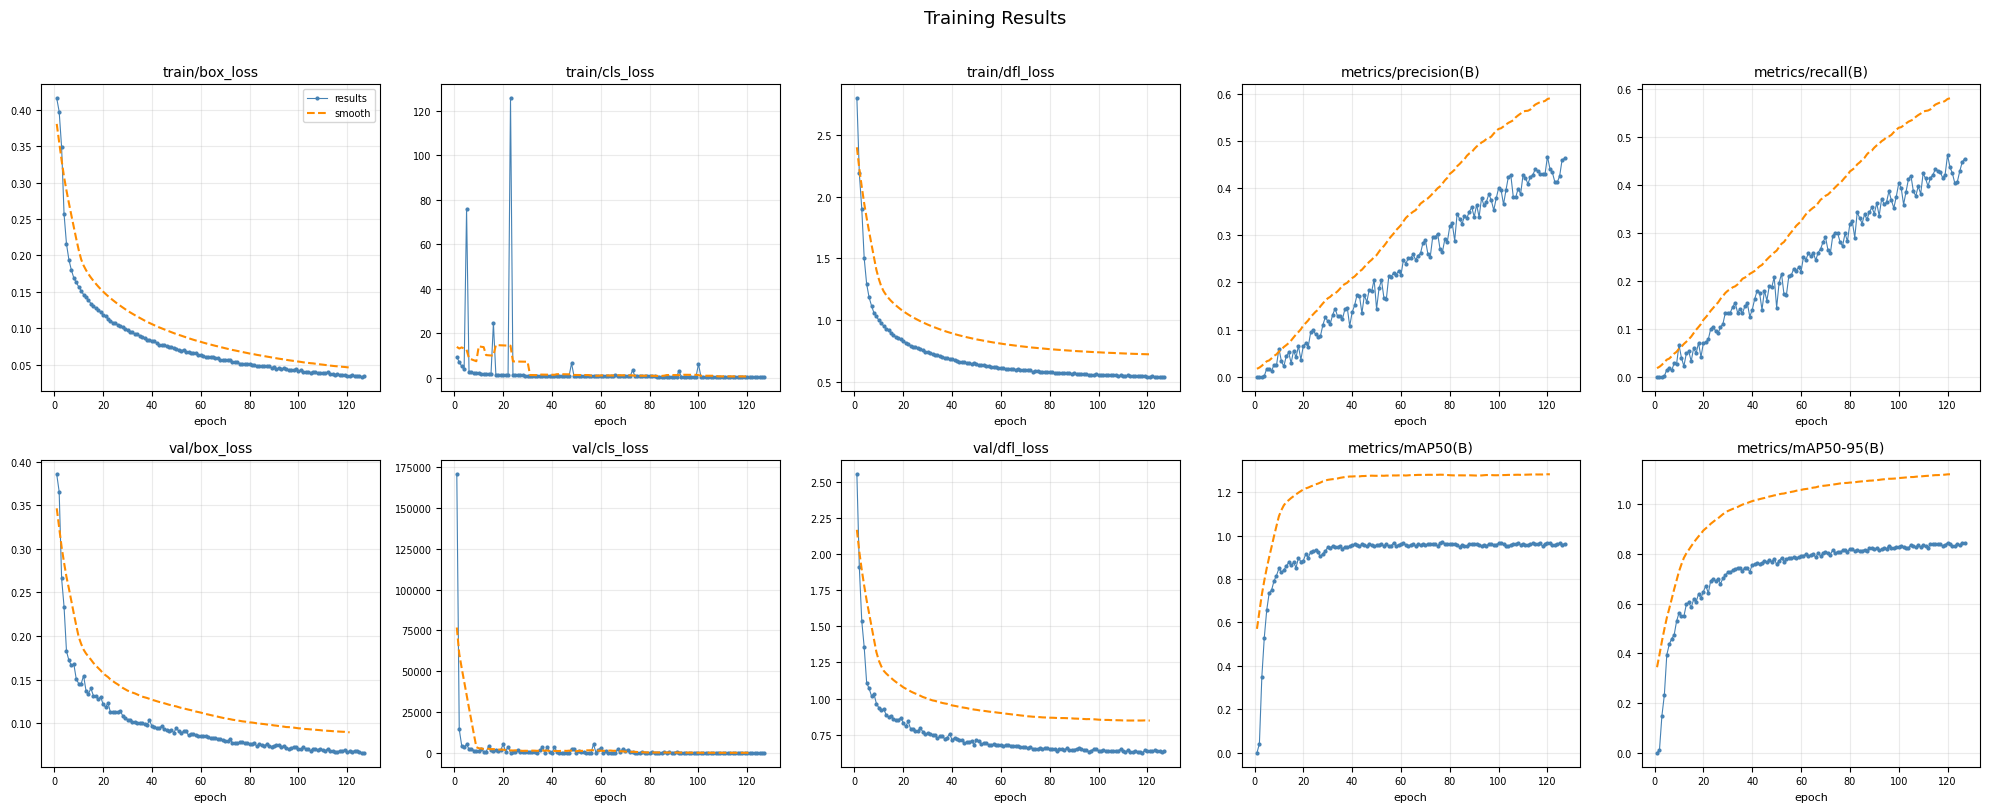

Plot saved to: checkpoints_1\train\results.png


In [9]:
import pandas as pd

def smooth(y, f=0.05):
    """Exponential moving average — matches the orange smoothed line in the reference."""
    nf = round(len(y) * f * 2 + 1)
    if nf < 3:
        return y
    p = np.ones(nf // 2)
    w = np.concatenate([p, p * 2, p]) / (p.sum() * 2 + p.sum())
    y_padded = np.concatenate([y[0:1] * p, y, y[-1:] * p])
    return np.convolve(y_padded, w, mode='valid')


df = pd.read_csv(csv_path)

# columns to plot — (csv_col, display_title)
plots = [
    # top row
    ('train/box_loss',          'train/box_loss'),
    ('train/cls_loss',          'train/cls_loss'),
    ('train/dfl_loss',          'train/dfl_loss'),
    ('metrics/precision(B)',    'metrics/precision(B)'),
    ('metrics/recall(B)',       'metrics/recall(B)'),
    # bottom row
    ('val/box_loss',            'val/box_loss'),
    ('val/cls_loss',            'val/cls_loss'),
    ('val/dfl_loss',            'val/dfl_loss'),
    ('metrics/mAP50(B)',        'metrics/mAP50(B)'),
    ('metrics/mAP50-95(B)',     'metrics/mAP50-95(B)'),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

epochs = df['epoch'].values

for ax, (col, title) in zip(axes, plots):
    if col not in df.columns:
        ax.set_visible(False)
        continue

    y = df[col].values.astype(float)

    # raw results (blue dots + line)
    ax.plot(epochs, y, color='steelblue', linewidth=0.8,
            marker='o', markersize=2, label='results')

    # smoothed (orange dashed)
    y_smooth = smooth(y)
    ax.plot(epochs[:len(y_smooth)], y_smooth,
            color='darkorange', linewidth=1.5,
            linestyle='--', label='smooth')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('epoch', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.25)

    # only show legend on first subplot
    if title == 'train/box_loss':
        ax.legend(fontsize=7)

fig.suptitle('Training Results', fontsize=13, y=1.01)
plt.tight_layout()

plot_path = SAVE_DIR / 'results.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to: {plot_path}')

# for verification of files

In [ ]:
def parse_data_config(yaml_path='dataset/data.yaml'):
    
    path = Path(yaml_path)

    if not path.exists():
        print(f"Error: Could not find '{yaml_path}'")
        return None

    try:
        with open(path, 'r', encoding='utf-8') as f:
            data = yaml.safe_load(f)

        config = {
            'train': data.get('train'),
            'val': data.get('val'),
            'test': data.get('test'),
            'nc': data.get('nc')
        }

        return config

    except yaml.YAMLError as exc:
        print(f"Error parsing YAML file: {exc}")
        return None


In [5]:
config = parse_data_config('dataset/data.yaml')
if config:
    print(f"Training folder: {config['train']}")
    print(f"Validation folder: {config['val']}")
    print(f"Test folder: {config.get('test', 'Not specified')}")
    print(f"Number of classes (nc): {config['nc']}")

Training folder: dataset/train
Validation folder: dataset/valid
Test folder: dataset/test
Number of classes (nc): 1


In [6]:
import random
import cv2

In [7]:
def visualize_samples(img_dir, label_dir, num_samples = 2):
  all_images = os.listdir(img_dir)
  samples = random.sample(all_images, num_samples)

  plt.figure(figsize = (10, 5))

  for i, img_name in enumerate(samples):
    img_path = os.path.join(img_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_h, img_w, _ = img.shape

    label_name = img_name.replace('.jpg', '.txt')
    label_path = os.path.join(label_dir, label_name)

    if os.path.exists(label_path):
      with open(label_path, 'r') as f:
        for line in f.readlines():
          cls, x_c, y_c, w, h = map(float, line.split())
          x_center, y_center = int(x_c * img_w), int(y_c * img_h)
          box_width, box_height = int(w*img_w), int(h*img_w)

          x1 = int(x_center - box_width / 2)
          y1 = int(y_center - box_height / 2)
          x2 = int(x_center + box_width / 2)
          y2 = int(y_center + box_height / 2)

          cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"image{i+1}")
    plt.axis('off')

  plt.tight_layout()
  plt.show()


In [ ]:
print("Training Samples:")
visualize_samples(config["train"]+"/images", config["train"]+"/labels", 2)
print("Validation Samples:")
visualize_samples(config["val"]+"/images", config["val"]+"/labels", 2)
print("Test Samples:")
visualize_samples(config["test"]+"/images", config["test"]+"/labels", 2)
